## Введение 

**Цель работы:**
 
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Задачи:**

Провести обучение модели линейной регрессии на датасете с Kaggle:

1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

7. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# Описание датасета
В работе используется набор данных Parkinsons Telemonitoring, содержащий биомедицинские характеристики голоса пациентов с болезнью Паркинсона. 
Информация об атрибутах датасета
Целевая переменная: motor_UPDRS — оценка двигательных нарушений по шкале UPDRS, 
- subject# — идентификатор пациента
- age — возраст пациента
- sex — пол пациента
- test_time — время проведения измерения относительно начала наблюдения
- total_UPDRS — общая оценка состояния пациента по шкале UPDRS
- Jitter(%), Jitter(Abs), Jitter:RAP, Jitter:PPQ5, Jitter:DDP — показатели вариабельности частоты голосового сигнала
- Shimmer, Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, Shimmer:APQ11, Shimmer:DDA — показатели вариабельности амплитуды голосового сигнала
- NHR — отношение шума к гармонической составляющей
- HNR — отношение гармонической составляющей к шуму
- RPDE — показатель нелинейной динамики голосового сигнала
- DFA — показатель фрактальных свойств голосового сигнала
- PPE — показатель вариабельности основной частоты голоса

In [238]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.decomposition import PCA

data = pd.read_csv('parkinsons_updrs.data')

## Основные статистики:

In [239]:
print(f'Размер датасета: {data.shape}')
data.describe()

Размер датасета: (5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


## Анализ распределения признаков

Для анализа распределения количественных признаков построены гистограммы и проведена проверка соответствия нормальному распределению с помощью критерия Колмогорова–Смирнова при уровне значимости \(alpha=0,05\). Идентификатор пациента subject# и бинарный признак sex из анализа нормальности исключены.

Признак: age
P-value: 0.0000000000
D: 0.0830
Результат: Не близко к нормальному


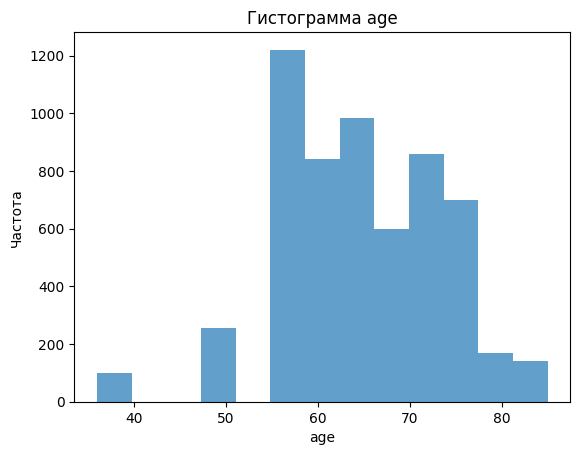


Признак: test_time
P-value: 0.0000000000
D: 0.0700
Результат: Не близко к нормальному


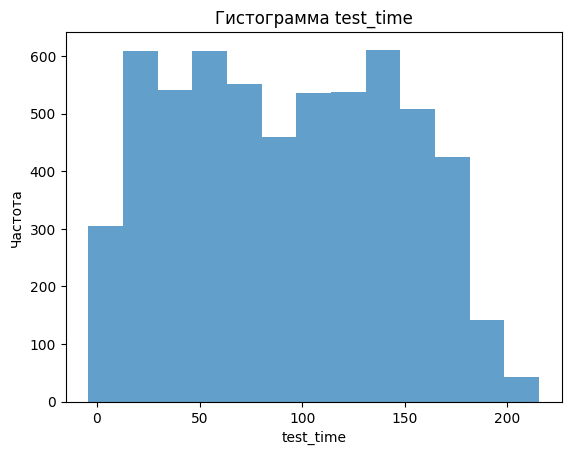


Признак: motor_UPDRS
P-value: 0.0000000000
D: 0.0615
Результат: Не близко к нормальному


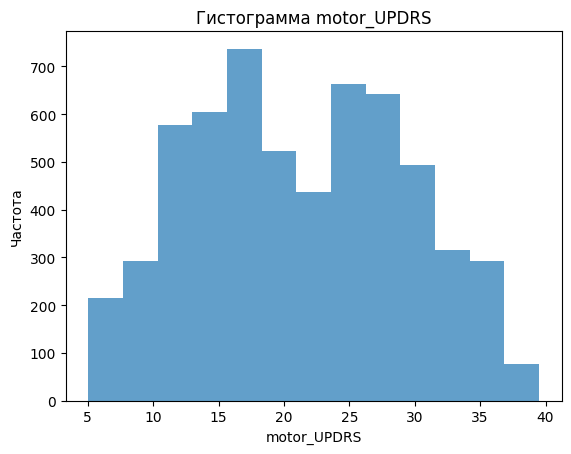


Признак: total_UPDRS
P-value: 0.0000000000
D: 0.0578
Результат: Не близко к нормальному


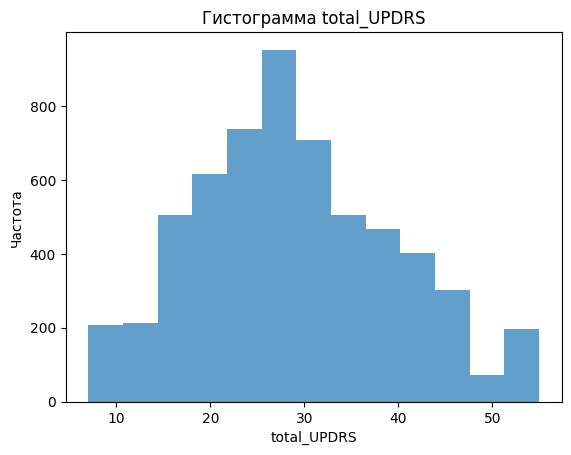


Признак: Jitter(%)
P-value: 0.0000000000
D: 0.2111
Результат: Не близко к нормальному


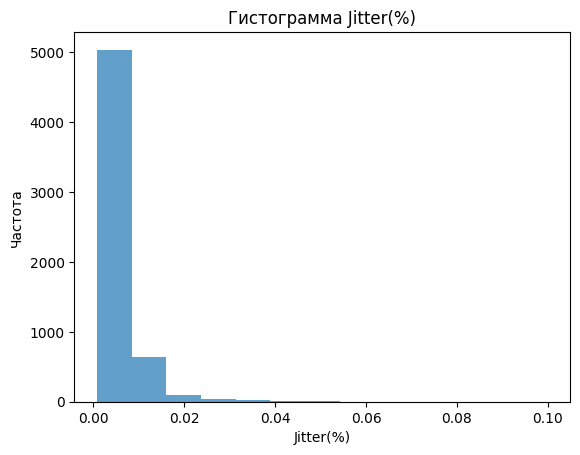


Признак: Jitter(Abs)
P-value: 0.0000000000
D: 0.1519
Результат: Не близко к нормальному


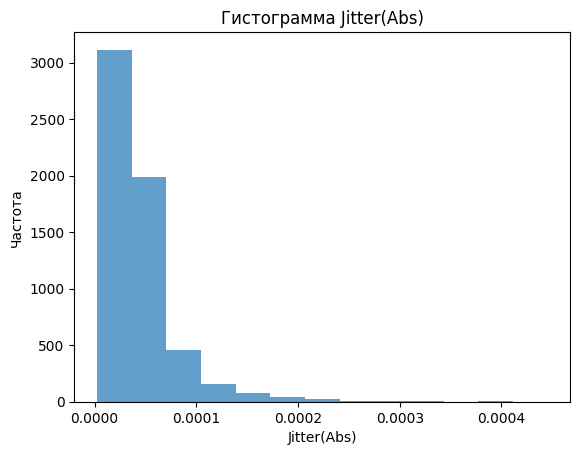


Признак: Jitter:RAP
P-value: 0.0000000000
D: 0.2245
Результат: Не близко к нормальному


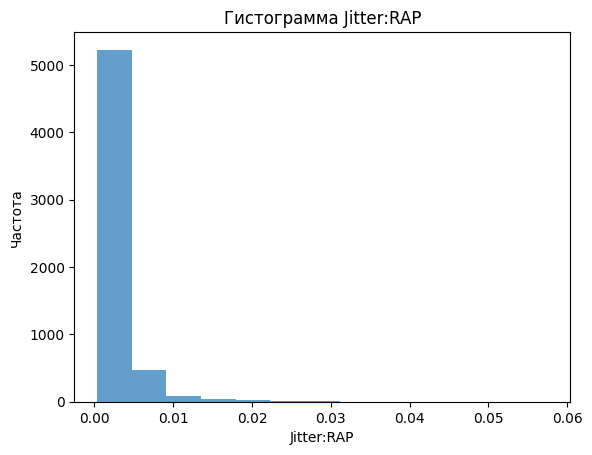


Признак: Jitter:PPQ5
P-value: 0.0000000000
D: 0.2480
Результат: Не близко к нормальному


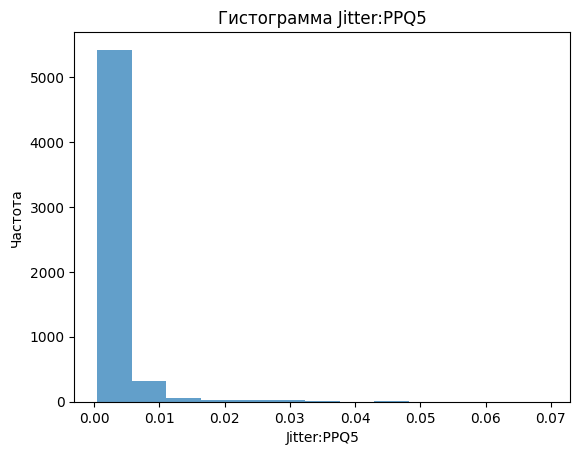


Признак: Jitter:DDP
P-value: 0.0000000000
D: 0.2242
Результат: Не близко к нормальному


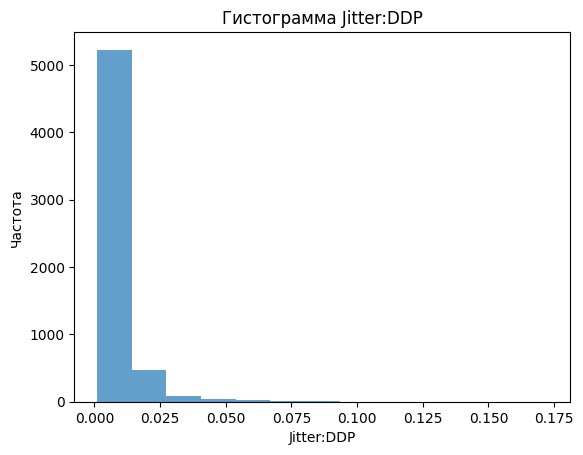


Признак: Shimmer
P-value: 0.0000000000
D: 0.1633
Результат: Не близко к нормальному


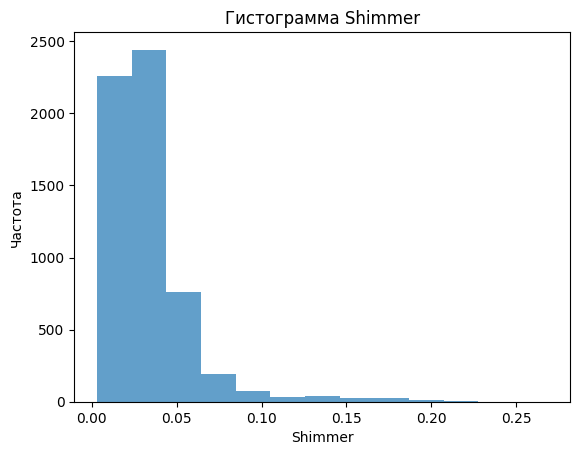


Признак: Shimmer(dB)
P-value: 0.0000000000
D: 0.1603
Результат: Не близко к нормальному


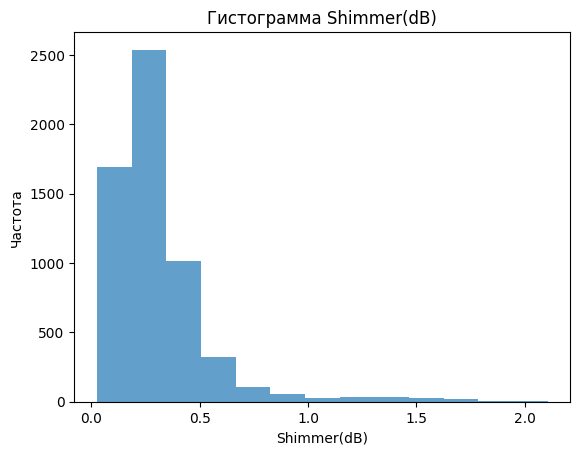


Признак: Shimmer:APQ3
P-value: 0.0000000000
D: 0.1560
Результат: Не близко к нормальному


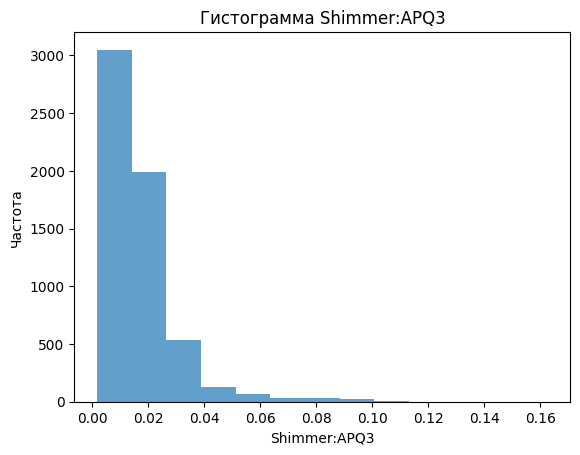


Признак: Shimmer:APQ5
P-value: 0.0000000000
D: 0.1654
Результат: Не близко к нормальному


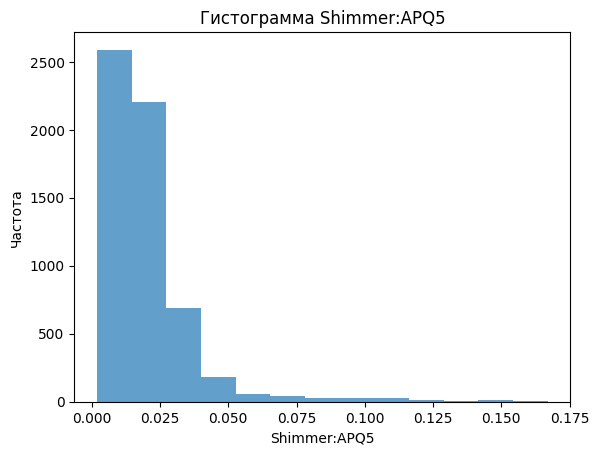


Признак: Shimmer:APQ11
P-value: 0.0000000000
D: 0.1487
Результат: Не близко к нормальному


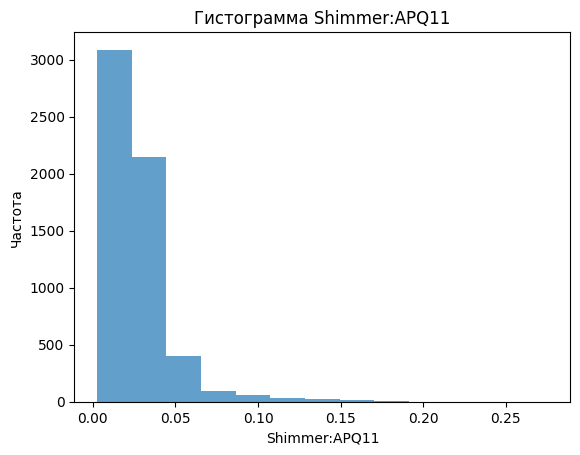


Признак: Shimmer:DDA
P-value: 0.0000000000
D: 0.1560
Результат: Не близко к нормальному


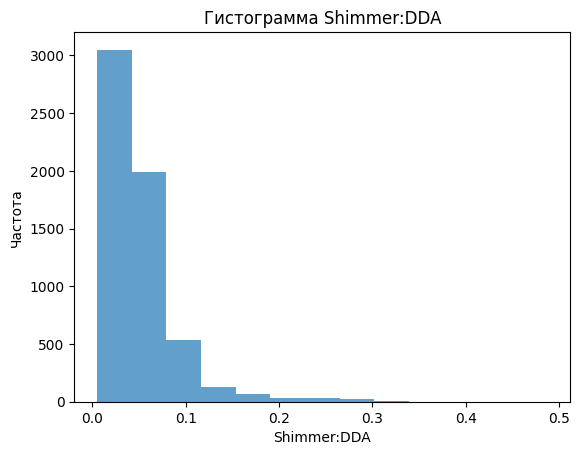


Признак: NHR
P-value: 0.0000000000
D: 0.3002
Результат: Не близко к нормальному


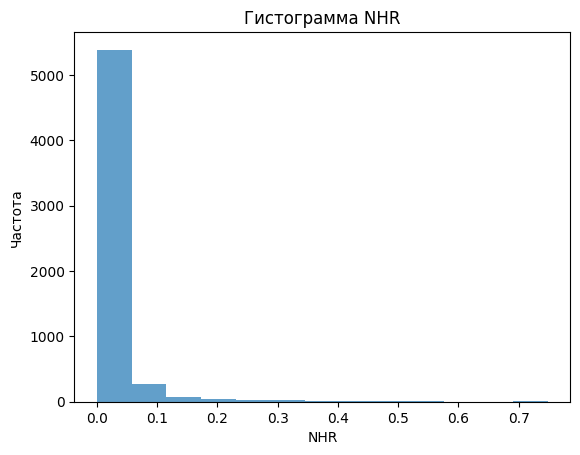


Признак: HNR
P-value: 0.0000000000
D: 0.0526
Результат: Не близко к нормальному


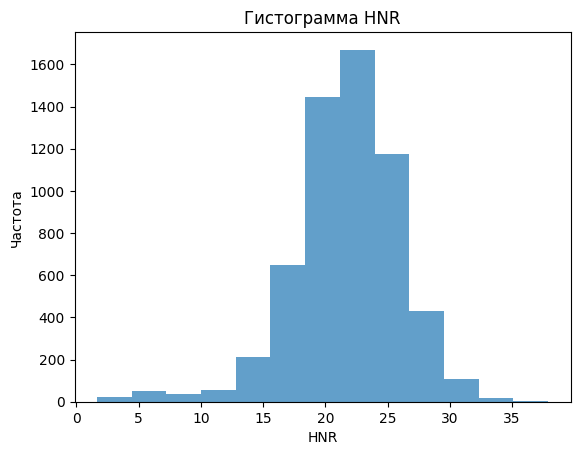


Признак: RPDE
P-value: 0.0205421647
D: 0.0197
Результат: Не близко к нормальному


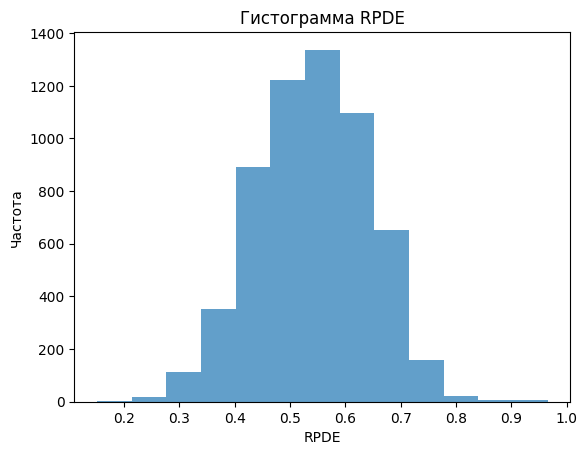


Признак: DFA
P-value: 0.0000000000
D: 0.0654
Результат: Не близко к нормальному


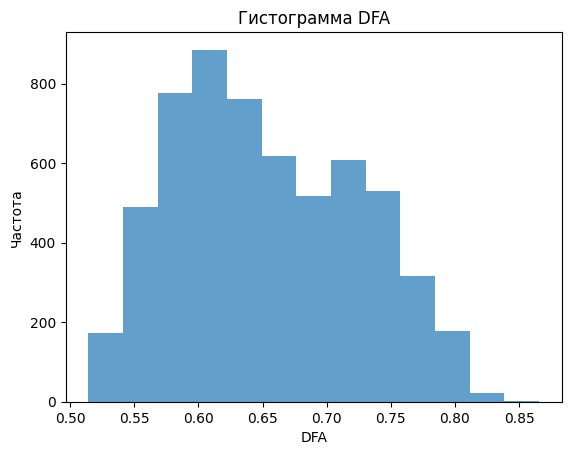


Признак: PPE
P-value: 0.0000000000
D: 0.0703
Результат: Не близко к нормальному


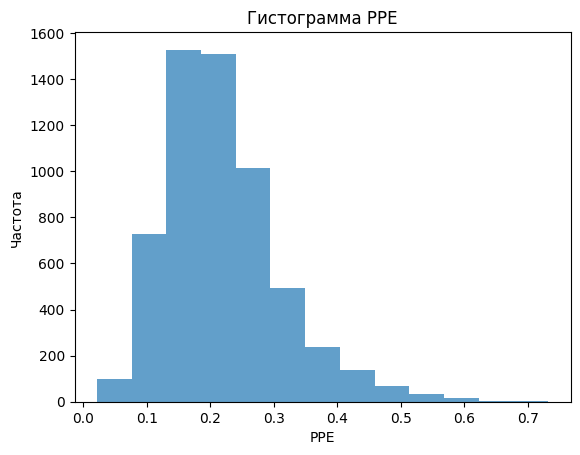

In [240]:
variables = [
    col for col in data.columns
    if col not in ['subject#', 'sex']
]

alpha = 0.05

for variable in variables:
    count = len(data[variable])
    mean = np.mean(data[variable])
    std = np.std(data[variable])

    sterdgess = math.floor(1 + 3.322 * math.log10(count))

    D, p_value = stats.kstest(
        data[variable],
        'norm',
        args=(mean, std)
    )

    print(f'Признак: {variable}')
    print(f'P-value: {p_value:.10f}')
    print(f'D: {D:.4f}')
    print(
        'Результат:',
        'Близко к нормальному'
        if p_value > alpha
        else 'Не близко к нормальному'
    )

    plt.hist(data[variable], bins=sterdgess, alpha=0.7)
    plt.xlabel(variable)
    plt.ylabel('Частота')
    plt.title(f'Гистограмма {variable}')
    plt.show()

    print()

### Распределение переменной sex

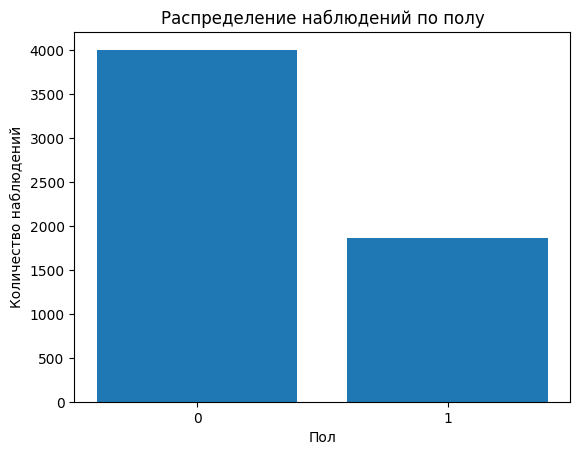

sex
0    4008
1    1867
Name: count, dtype: int64


In [241]:
sex_counts = data['sex'].value_counts().sort_index()

plt.bar(sex_counts.index.astype(str), sex_counts.values)
plt.xlabel('Пол')
plt.ylabel('Количество наблюдений')
plt.title('Распределение наблюдений по полу')
plt.xticks([0, 1])
plt.show()

print(sex_counts)

## Предобработка данных:

**Количество пропусков в каждом столбце:**

In [242]:
print(data.isnull().sum())

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64


Проверка на пропущенные значения показала их полное отсутствие во всех столбцах датасета.

**Количество нулей в каждом столбце**

In [243]:
zero_counts = (data == 0).sum()
print(zero_counts)

subject#            0
age                 0
sex              4008
test_time           0
motor_UPDRS         0
total_UPDRS         0
Jitter(%)           0
Jitter(Abs)         0
Jitter:RAP          0
Jitter:PPQ5         0
Jitter:DDP          0
Shimmer             0
Shimmer(dB)         0
Shimmer:APQ3        0
Shimmer:APQ5        0
Shimmer:APQ11       0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
PPE                 0
dtype: int64


Нулевые значения обнаружены только в признаке sex, где значение 0 является кодом одной из категорий, поэтому данные значения не требуют обработки.

In [244]:
X = data.drop(columns=['subject#'])

print('Количество независимых признаков:', X.shape[1])

Количество независимых признаков: 21


Из набора независимых признаков исключены subject#, поскольку он является идентификатором пациента

## Матрица корреляций

Поскольку проведённая ранее проверка показала, что распределения исследуемых количественных признаков отличаются от нормального, для оценки корреляционной связи используется коэффициент корреляции Спирмена.

In [245]:
corr_matrix = X.corr(method='spearman')
corr_matrix

,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
age,1.000000,-0.040469,0.011775,0.302676,0.318726,0.170554,0.131111,0.138750,0.168937,0.138766,...,0.276990,0.241254,0.261343,0.300729,0.241248,0.171385,-0.184483,0.134948,-0.090895,0.183722
sex,-0.040469,1.000000,-0.004497,-0.038613,-0.069050,-0.094885,-0.341918,-0.000453,-0.102964,-0.000483,...,-0.111170,-0.072878,-0.110871,-0.152324,-0.072873,-0.063660,0.075811,-0.159660,-0.152338,-0.168153
test_time,0.011775,-0.004497,1.000000,0.058746,0.061699,-0.007409,-0.008382,-0.016707,-0.004507,-0.016677,...,-0.020741,-0.018772,-0.022814,-0.029707,-0.018769,-0.025681,0.032616,-0.038564,0.018448,-0.004099
motor_UPDRS,0.302676,-0.038613,0.058746,1.000000,0.957818,0.127905,0.072467,0.106679,0.120092,0.106731,...,0.140127,0.113784,0.121267,0.163761,0.113785,0.135626,-0.158061,0.117980,-0.131377,0.163229
total_UPDRS,0.318726,-0.069050,0.061699,0.957818,1.000000,0.129237,0.104178,0.109214,0.118347,0.109251,...,0.139915,0.119909,0.124940,0.161151,0.119912,0.143972,-0.162284,0.149926,-0.141538,0.155236
Jitter(%),0.170554,-0.094885,-0.007409,0.127905,0.129237,1.000000,0.902065,0.956166,0.959100,0.956176,...,0.673114,0.616051,0.622316,0.635287,0.616048,0.797751,-0.756633,0.529491,0.440976,0.845357
Jitter(Abs),0.131111,-0.341918,-0.008382,0.072467,0.104178,0.902065,1.000000,0.821846,0.886542,0.821845,...,0.634172,0.579700,0.606298,0.634621,0.579697,0.745656,-0.756796,0.634311,0.494995,0.804174
Jitter:RAP,0.138750,-0.000453,-0.016707,0.106679,0.109214,0.956166,0.821846,1.000000,0.948001,0.999996,...,0.657433,0.632204,0.616982,0.598533,0.632201,0.745099,-0.726644,0.445449,0.430145,0.772361
Jitter:PPQ5,0.168937,-0.102964,-0.004507,0.120092,0.118347,0.959100,0.886542,0.948001,1.000000,0.948016,...,0.698519,0.657140,0.666872,0.668118,0.657138,0.752913,-0.790342,0.510383,0.480241,0.843826
Jitter:DDP,0.138766,-0.000483,-0.016677,0.106731,0.109251,0.956176,0.821845,0.999996,0.948016,1.000000,...,0.657419,0.632185,0.616967,0.598526,0.632183,0.745088,-0.726643,0.445419,0.430199,0.772383


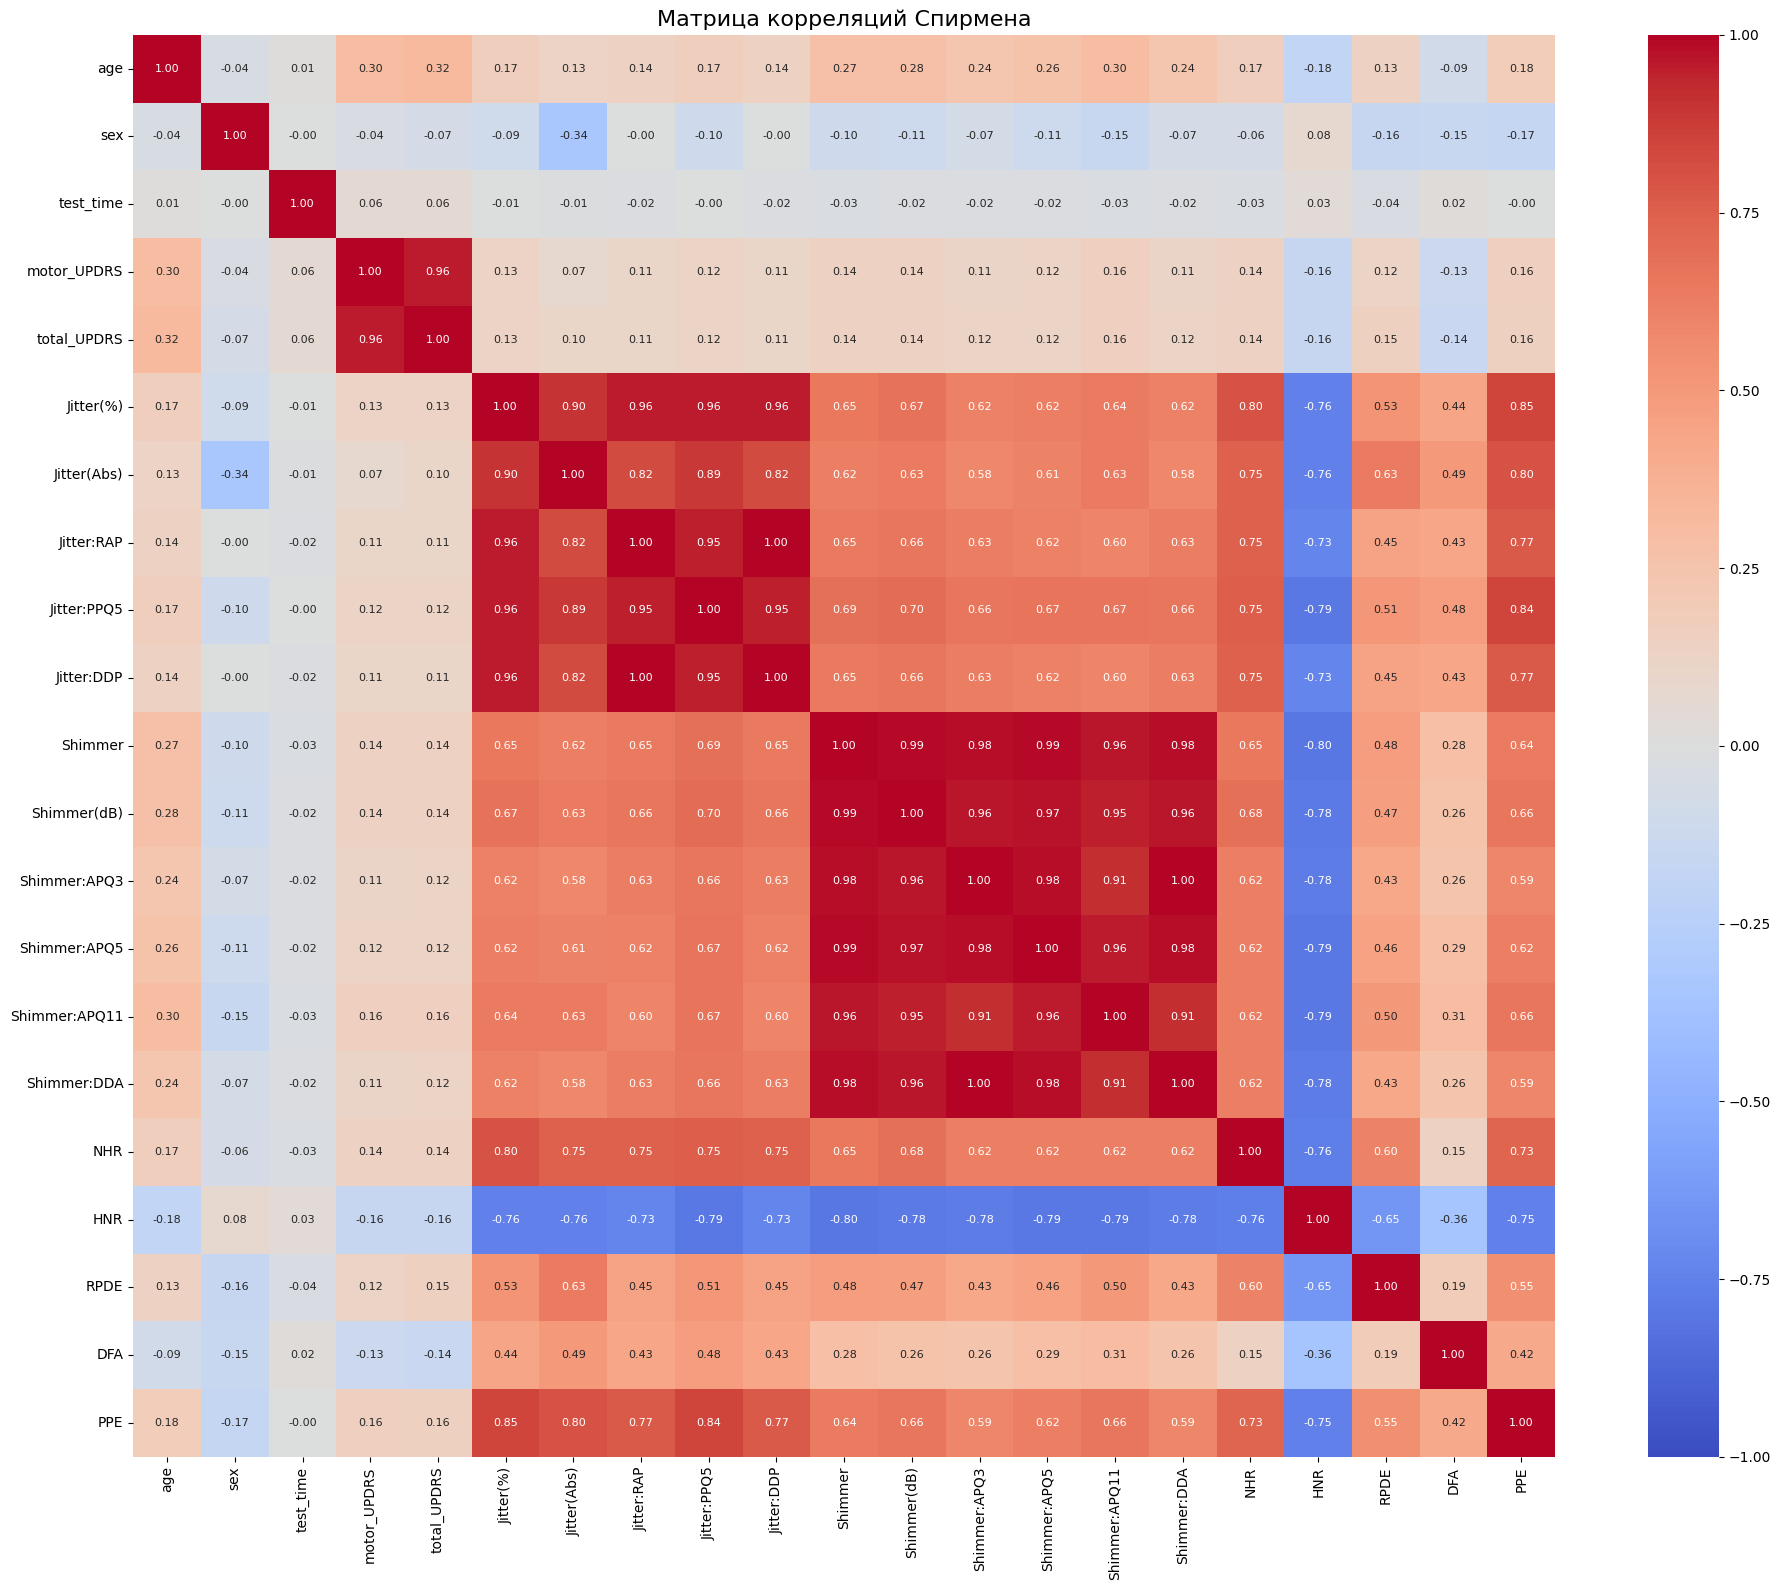

In [246]:
corr_matrix = X.corr(method='spearman')

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot_kws={'size': 8}
)

plt.title('Матрица корреляций Спирмена', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Между целевой переменной motor_UPDRS и показателем total_UPDRS выявлена очень сильная положительная корреляционная связь (\(r_s=0,96\)). Поскольку total_UPDRS является связанной итоговой оценкой по той же шкале UPDRS, данный признак исключён из дальнейшего построения модели.

Для выявления избыточных признаков были дополнительно выделены пары переменных с абсолютным значением коэффициента корреляции Спирмена >= 0,8. Такой уровень связи был принят как порог сильной корреляции между независимыми признаками.

In [247]:
corr_X = X.corr(method='spearman')

high_corr = []

for i in range(len(corr_X.columns)):
    for j in range(i):
        corr_value = corr_X.iloc[i, j]

        if abs(corr_value) >= 0.8:
            high_corr.append([
                corr_X.columns[i],
                corr_X.columns[j],
                corr_value
            ])

high_corr = pd.DataFrame(
    high_corr,
    columns=['Признак 1', 'Признак 2', 'Корреляция']
)

high_corr = high_corr.sort_values(
    'Корреляция',
    key=abs,
    ascending=False
)

high_corr

,Признак 1,Признак 2,Корреляция
23,Shimmer:DDA,Shimmer:APQ3,1.000000
9,Jitter:DDP,Jitter:RAP,0.999996
14,Shimmer:APQ5,Shimmer,0.990056
11,Shimmer(dB),Shimmer,0.986356
21,Shimmer:DDA,Shimmer,0.983187
12,Shimmer:APQ3,Shimmer,0.983187
24,Shimmer:DDA,Shimmer:APQ5,0.981303
16,Shimmer:APQ5,Shimmer:APQ3,0.981301
15,Shimmer:APQ5,Shimmer(dB),0.972345
13,Shimmer:APQ3,Shimmer(dB),0.963308


In [248]:
X = data.drop(columns=[
    'subject#',
    'motor_UPDRS',
    'total_UPDRS',
    'Jitter(Abs)',
    'Jitter:RAP',
    'Jitter:PPQ5',
    'Jitter:DDP',
    'Shimmer(dB)',
    'Shimmer:APQ3',
    'Shimmer:APQ5',
    'Shimmer:APQ11',
    'Shimmer:DDA',
    'PPE',
    'NHR'
])

y = data['motor_UPDRS']

После исключения сильно коррелирующих признаков корреляционная матрица была построена повторно для проверки оставшихся взаимосвязей

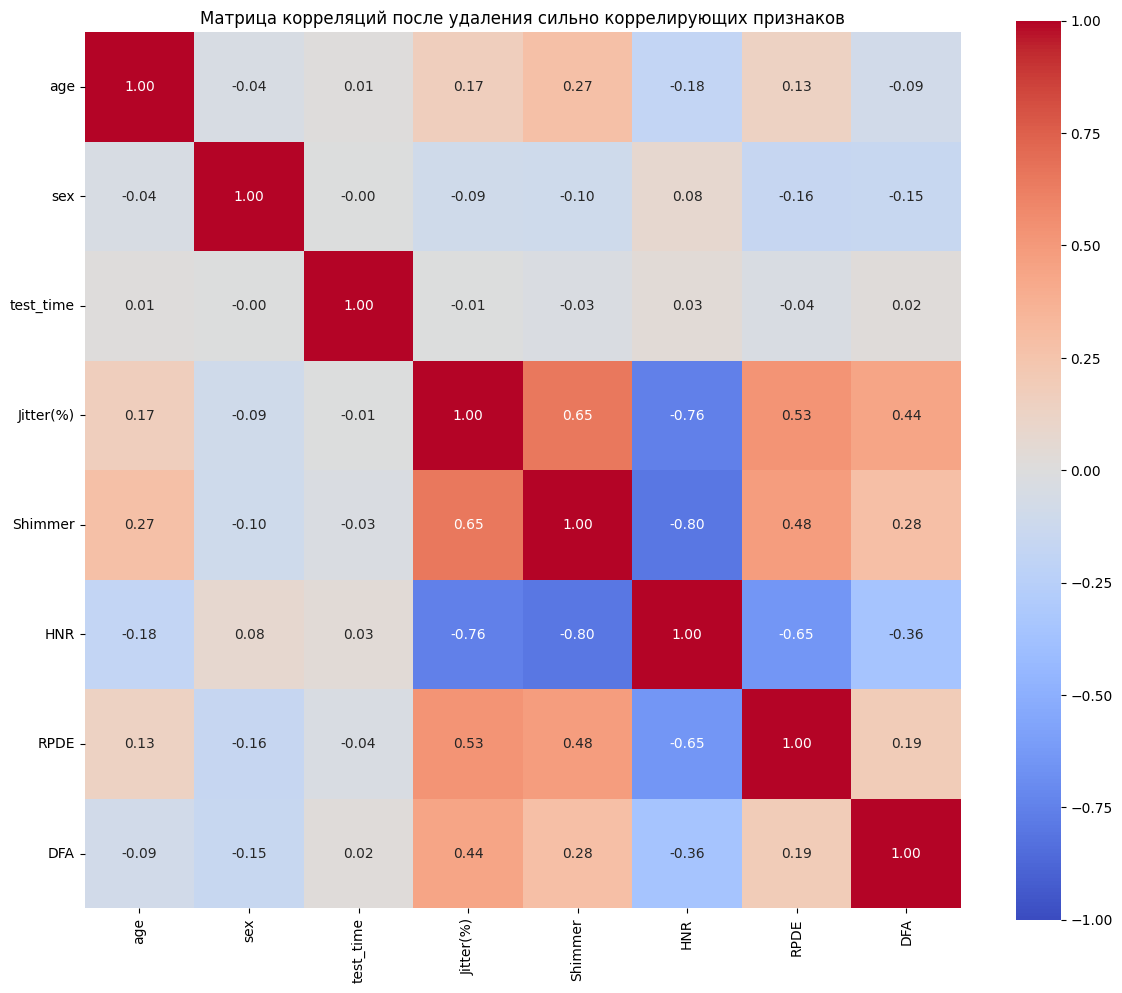

In [249]:
corr_matrix = X.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title('Матрица корреляций после удаления сильно коррелирующих признаков')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## VIF-коэффициент

Для окончательной оценки мультиколлинеарности далее рассчитываются коэффициенты VIF.

In [250]:
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i + 1)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values('VIF', ascending=False)

vif_display = vif_data.copy()
vif_display['VIF'] = vif_display['VIF'].round(0).astype(int)

print(vif_display)

     Feature  VIF
5        HNR    4
4    Shimmer    3
3  Jitter(%)    2
6       RPDE    2
7        DFA    1
1        sex    1
0        age    1
2  test_time    1


Значения VIF для всех оставшихся признаков не превышают 5, что свидетельствует о приемлемом уровне мультиколлинеарности.


## Построение регрессионных моделей

### Формируем X и y


In [251]:
y = data['motor_UPDRS']

print('Признаки:', X.columns.tolist())
print('Количество признаков:', X.shape[1])

Признаки: ['age', 'sex', 'test_time', 'Jitter(%)', 'Shimmer', 'HNR', 'RPDE', 'DFA']
Количество признаков: 8


### Делим данные на train и test (80/20)

In [252]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)

Обучающая выборка: (4700, 8)
Тестовая выборка: (1175, 8)


### Параметры кросс-валидации 

In [253]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Cтандартизация

Для моделей Lasso и Ridge выполнена стандартизация признаков, поскольку регуляризация чувствительна к их масштабу. Стандартизация и обучение модели объединены с помощью Pipeline, что позволяет выполнять преобразование данных отдельно на каждом этапе кросс-валидации и предотвращает утечку информации.

In [254]:
linear_model = LinearRegression()

lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0))
])

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

### Кросс-валидация трёх моделей

In [255]:
models = {
    'Линейная регрессия': linear_model,
    'Lasso': lasso_model,
    'Ridge': ridge_model
}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='r2'
    )

    print(f'{name}: средний R² = {scores["test_score"].mean():.4f}')

Линейная регрессия: средний R² = 0.1281
Lasso: средний R² = 0.0668
Ridge: средний R² = 0.1281


### Метрики
Для оценки качества использованы метрики RMSE, \(R^2\) и MAPE

In [256]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Модель': name,
        'RMSE': rmse,
        'R²': r2,
        'MAPE, %': mape
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

               Модель    RMSE      R²  MAPE, %
0  Линейная регрессия  7.6316  0.0876  39.2586
1               Lasso  7.7344  0.0628  41.6542
2               Ridge  7.6314  0.0876  39.2590


## Метод главных компонент

### Cтандартизация перед PCA

Перед PCA стандартизация обязательна, поскольку признаки имеют разные единицы измерения и масштабы.

In [257]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Первоначальный PCA

In [258]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

### Объяснённая дисперсия
Рассчитана доля объяснённой дисперсии каждой главной компоненты и накопленная дисперсия, показывающая долю информации, сохраняемую несколькими компонентами совместно

In [259]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(explained_variance, 1):
    print(f'PC{i}: {variance:.4f}')

print()

for i, variance in enumerate(cumulative_variance, 1):
    print(f'{i} компонент: {variance:.4f}')

PC1: 0.3742
PC2: 0.1467
PC3: 0.1333
PC4: 0.1251
PC5: 0.0928
PC6: 0.0707
PC7: 0.0387
PC8: 0.0185

1 компонент: 0.3742
2 компонент: 0.5209
3 компонент: 0.6542
4 компонент: 0.7793
5 компонент: 0.8721
6 компонент: 0.9428
7 компонент: 0.9815
8 компонент: 1.0000


### График каменистой осыпи
Вклад каждой компоненты отдельно

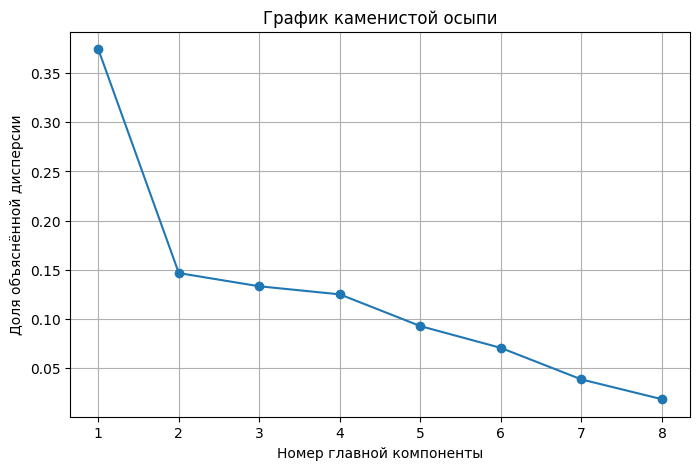

In [260]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('График каменистой осыпи')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()

plt.show()

### Накопленная объяснённая дисперсия
В качестве порогового значения принято сохранение не менее 95% исходной информации

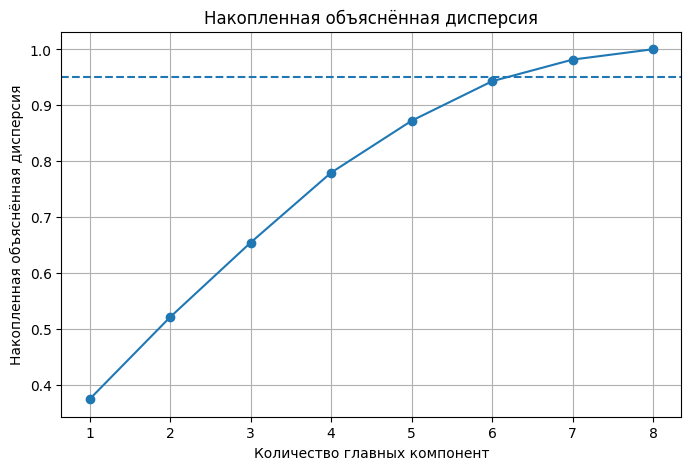

In [261]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(y=0.95, linestyle='--')

plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Накопленная объяснённая дисперсия')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid()

plt.show()

### Выбор количества компонент


In [262]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(
    'Количество компонент для сохранения 95% дисперсии:',
    n_components
)

Количество компонент для сохранения 95% дисперсии: 7


### Окончательное PCA с 7 компонентами

In [263]:
pca_final = PCA(n_components=n_components)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print('До PCA:', X_train.shape)
print('После PCA:', X_train_pca.shape)

До PCA: (4700, 8)
После PCA: (4700, 7)


В результате применения PCA размерность пространства признаков была уменьшена с 8 до 7 компонент с сохранением не менее 95% объяснённой дисперсии.

## Построение модели после PCA

### Кросс-валидация

In [264]:
models_pca = {
    'Линейная регрессия': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'Ridge': Ridge(alpha=1.0)
}

for name, model in models_pca.items():
    scores = cross_validate(
        model,
        X_train_pca,
        y_train,
        cv=cv,
        scoring='r2'
    )

    print(f'{name}: средний R² = {scores["test_score"].mean():.4f}')

Линейная регрессия: средний R² = 0.1124
Lasso: средний R² = 0.0842
Ridge: средний R² = 0.1124


### Обучение итоговой модели

In [265]:
results_pca = []

for name, model in models_pca.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results_pca.append({
        'Модель': name,
        'RMSE': rmse,
        'R²': r2,
        'MAPE, %': mape
    })

results_pca_df = pd.DataFrame(results_pca)

print(results_pca_df.round(4))

               Модель    RMSE      R²  MAPE, %
0  Линейная регрессия  7.6153  0.0914  39.4560
1               Lasso  7.6594  0.0809  40.8356
2               Ridge  7.6153  0.0914  39.4563


### Сравнение результатов до и после PCA

In [266]:
comparison = results_df.merge(
    results_pca_df,
    on='Модель',
    suffixes=(' до PCA', ' после PCA')
)

comparison = comparison[
    [
        'Модель',
        'RMSE до PCA', 'RMSE после PCA',
        'R² до PCA', 'R² после PCA',
        'MAPE, % до PCA', 'MAPE, % после PCA'
    ]
]

comparison.round(4)

,Модель,RMSE до PCA,RMSE после PCA,R² до PCA,R² после PCA,"MAPE, % до PCA","MAPE, % после PCA"
0,Линейная регрессия,7.6316,7.6153,0.0876,0.0914,39.2586,39.4560
1,Lasso,7.7344,7.6594,0.0628,0.0809,41.6542,40.8356
2,Ridge,7.6314,7.6153,0.0876,0.0914,39.2590,39.4563


## Заключение

В результате работы были построены и оценены линейная, Lasso- и Ridge-регрессии. Применение PCA позволило снизить размерность данных с 8 до 7 компонент с сохранением не менее 95% объяснённой дисперсии. После PCA качество моделей в целом незначительно улучшилось: для линейной и Ridge-регрессии немного увеличился \(R^2\) и снизился RMSE, а Lasso-регрессия показала улучшение всех рассматриваемых метрик. Таким образом, PCA позволил сократить размерность данных без потери качества моделей.